In [1]:
!pip install -q kaggle scikit-image

In [2]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Kaggle configured successfully!")

Kaggle configured successfully!


In [8]:
!wget -q "https://github.com/laxmimerit/dog-cat-full-dataset/archive/refs/heads/master.zip" -O cats_dogs.zip

print("Download completed!")

Download completed!


In [9]:
import zipfile

with zipfile.ZipFile("cats_dogs.zip", "r") as zip_ref:
    zip_ref.extractall("cats_dogs")

print("Dataset extracted!")

Dataset extracted!


In [10]:
import os

for root, dirs, files in os.walk("cats_dogs"):
    if files:
        print(root, "->", len(files), "files")

cats_dogs/dog-cat-full-dataset-master -> 1 files
cats_dogs/dog-cat-full-dataset-master/data/train/cats -> 10000 files
cats_dogs/dog-cat-full-dataset-master/data/train/dogs -> 9989 files
cats_dogs/dog-cat-full-dataset-master/data/test/cats -> 2500 files
cats_dogs/dog-cat-full-dataset-master/data/test/dogs -> 2500 files


In [11]:
import os

base_path = "cats_dogs/dog-cat-full-dataset-master/data"

cat_path = os.path.join(base_path, "train/cats")
dog_path = os.path.join(base_path, "train/dogs")

cat_images = os.listdir(cat_path)[:1000]
dog_images = os.listdir(dog_path)[:1000]

print("Cats:", len(cat_images))
print("Dogs:", len(dog_images))
print("Total:", len(cat_images) + len(dog_images))

Cats: 1000
Dogs: 1000
Total: 2000


In [12]:
from skimage.io import imread
from skimage.transform import resize
from skimage.feature import hog
import numpy as np
import os

X = []
y = []

print("Processing images...")

# Process cats
for filename in cat_images:
    image_path = os.path.join(cat_path, filename)

    image = imread(image_path)
    image = resize(image, (64, 64))

    # Convert RGB to grayscale
    if image.ndim == 3:
        image = np.mean(image, axis=2)

    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )

    X.append(features)
    y.append(0)

# Process dogs
for filename in dog_images:
    image_path = os.path.join(dog_path, filename)

    image = imread(image_path)
    image = resize(image, (64, 64))

    if image.ndim == 3:
        image = np.mean(image, axis=2)

    features = hog(
        image,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2)
    )

    X.append(features)
    y.append(1)

X = np.array(X)
y = np.array(y)

print("Feature extraction completed!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Processing images...
Feature extraction completed!
X shape: (2000, 1764)
y shape: (2000,)


In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 1600
Testing samples: 400


In [14]:
from sklearn.svm import SVC

print("Training SVM...")

svm_model = SVC(
    kernel='linear',
    C=1.0
)

svm_model.fit(X_train, y_train)

print("SVM training completed!")

Training SVM...
SVM training completed!


In [15]:
from sklearn.metrics import accuracy_score

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", round(accuracy * 100, 2), "%")

Accuracy: 0.695
Accuracy (%): 69.5 %


In [16]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Cat", "Dog"]
))

              precision    recall  f1-score   support

         Cat       0.69      0.71      0.70       200
         Dog       0.70      0.68      0.69       200

    accuracy                           0.69       400
   macro avg       0.70      0.70      0.69       400
weighted avg       0.70      0.69      0.69       400



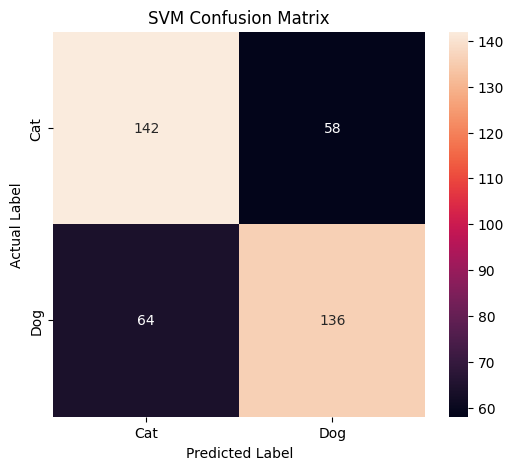

In [17]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Cat", "Dog"],
    yticklabels=["Cat", "Dog"]
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("SVM Confusion Matrix")

plt.show()

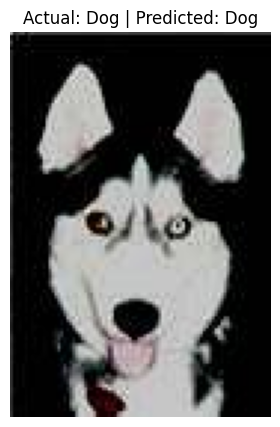

In [18]:
import random
import matplotlib.pyplot as plt
from skimage.io import imread
from skimage.transform import resize
from skimage.feature import hog

# Select a random test image
test_cat_path = os.path.join(base_path, "test/cats")
test_dog_path = os.path.join(base_path, "test/dogs")

actual_class = random.choice(["Cat", "Dog"])

if actual_class == "Cat":
    test_folder = test_cat_path
    test_label = 0
else:
    test_folder = test_dog_path
    test_label = 1

test_file = random.choice(os.listdir(test_folder))
image_path = os.path.join(test_folder, test_file)

image = imread(image_path)

# Preprocess
resized = resize(image, (64, 64))

if resized.ndim == 3:
    gray = np.mean(resized, axis=2)
else:
    gray = resized

# HOG features
features = hog(
    gray,
    orientations=9,
    pixels_per_cell=(8, 8),
    cells_per_block=(2, 2)
)

# Prediction
prediction = svm_model.predict([features])[0]

predicted_class = "Cat" if prediction == 0 else "Dog"

plt.figure(figsize=(5, 5))
plt.imshow(image)
plt.axis("off")

plt.title(
    f"Actual: {actual_class} | Predicted: {predicted_class}"
)

plt.show()

In [19]:
import joblib

joblib.dump(svm_model, "svm_cats_dogs_model.pkl")

print("SVM model saved successfully!")

SVM model saved successfully!


In [20]:
from google.colab import files

files.download("svm_cats_dogs_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>